In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


# Decision Tree Classification Model - Sleep Health Dataset
# Wytrenowanie modelu klasyfikacyjnego do przewidywania zmiennej 'felt_rested'
# na podstawie zbioru sleep_health_dataset.csv


## WCZYTANIE I EKSPLORACJA DANYCH


In [18]:
file_path = "../resources/sleep_health_dataset.csv"
df = pd.read_csv(file_path)

df = df.drop('person_id', axis=1)

print(f"\nRozmiar calego zbioru danych: {df.shape[0]} wierszy x {df.shape[1]} kolumn")

df.info()
df.describe().round(2)



Rozmiar calego zbioru danych: 100000 wierszy x 31 kolumn
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   gender                       100000 non-null  str    
 2   occupation                   100000 non-null  str    
 3   bmi                          100000 non-null  float64
 4   country                      100000 non-null  str    
 5   sleep_duration_hrs           100000 non-null  float64
 6   sleep_quality_score          100000 non-null  float64
 7   rem_percentage               100000 non-null  float64
 8   deep_sleep_percentage        100000 non-null  float64
 9   sleep_latency_mins           100000 non-null  int64  
 10  wake_episodes_per_night      100000 non-null  int64  
 11  caffeine_mg_before_bed       100000 non-null  int64  
 12  alcohol_unit

,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,...,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,34.71,26.29,6.42,4.87,20.24,20.25,19.84,3.35,38.85,0.60,...,14.94,5.73,7.13,66.57,0.56,0.08,20.54,1.20,59.23,0.39
std,11.04,4.48,1.27,1.51,3.41,4.25,7.58,1.92,69.40,1.06,...,21.39,1.62,3.48,7.23,0.50,0.28,2.90,0.79,22.25,0.49
min,18.00,16.00,3.00,1.00,10.00,5.00,1.00,0.00,0.00,0.00,...,0.00,1.00,0.00,45.00,0.00,0.00,15.00,-1.00,0.00,0.00
25%,26.00,23.20,5.53,3.80,18.00,17.40,14.00,2.00,0.00,0.00,...,0.00,4.80,4.70,62.00,0.00,0.00,18.50,0.67,44.20,0.00
50%,33.00,26.30,6.36,4.90,20.30,20.30,19.00,3.00,0.00,0.00,...,0.00,5.80,7.40,67.00,1.00,0.00,20.50,1.20,60.40,0.00
75%,42.00,29.30,7.27,6.00,22.60,23.20,25.00,5.00,80.00,1.00,...,30.00,6.80,9.70,71.00,1.00,0.00,22.50,1.74,75.80,1.00
max,69.00,45.00,10.50,10.00,30.00,30.00,58.00,8.00,400.00,6.00,...,116.00,10.00,18.00,99.00,1.00,1.00,28.00,3.00,100.00,1.00


## PREPROCESSING DANYCH


In [3]:
# Usuniecie kolumny person_id jesli istnieje
if 'person_id' in df.columns:
    df = df.drop('person_id', axis=1)

# Identyfikacja zmiennej celu i cech
target_col = 'felt_rested'
y = df[target_col]
X = df.drop(columns=[target_col])

print("\n" + "=" * 70)
print("PREPROCESSING DANYCH")
print("=" * 70)
print(f"\nZmienne niezalezne (cechy): {X.columns.tolist()}")
print(f"\nZmienna zalezna (target): {target_col}")
print(f"Klasy: {sorted(y.unique())}")
print(f"\nRozklad klas:")
print(y.value_counts())
print(f"\nProcent klas:")
print(y.value_counts(normalize=True) * 100)



PREPROCESSING DANYCH

Zmienne niezalezne (cechy): ['age', 'gender', 'occupation', 'bmi', 'country', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk']

Zmienna zalezna (target): felt_rested
Klasy: [np.int64(0), np.int64(1)]

Rozklad klas:
felt_rested
0    60988
1    39012
Name: count, dtype: int64

Procent klas:
felt_rested
0    60.988
1    39.012
Name: proportion, dtype: float64


In [4]:
# Preprocessing: obsluga zmiennych kategorycznych
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nZmienne kategoryczne: {categorical_cols}")
print(f"Zmienne numeryczne: {numerical_cols}")

# Kodowanie zmiennych kategorycznych
label_encoders = {}
X_processed = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"\nKodowanie {col}:")
    for i, class_name in enumerate(le.classes_):
        print(f"  {class_name} -> {i}")

# Kodowanie zmiennej celu jesli jest kategoryczna
if y.dtype == 'object':
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    print(f"\nKodowanie zmiennej celu {target_col}:")
    for i, class_name in enumerate(le_target.classes_):
        print(f"  {class_name} -> {i}")
else:
    y_encoded = y
    le_target = None



Zmienne kategoryczne: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk']
Zmienne numeryczne: ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'cognitive_performance_score']

Kodowanie gender:
  Female -> 0
  Male -> 1
  Other -> 2

Kodowanie occupation:
  Doctor -> 0
  Driver -> 1
  Freelancer -> 2
  Homemaker -> 3
  Lawyer -> 4
  Manager -> 5
  Nurse -> 6
  Retired -> 7
  Sales -> 8
  Software Engineer -> 9
  Student -> 10
  Teacher -> 11

Kodowanie country:
  Australia -> 0
  Brazil -> 1
  Canada -> 2
  France -> 3
  Germany -

C:\Users\Piotrek\AppData\Local\Temp\ipykernel_28080\900600369.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


## PODZIAŁ NA ZBIÓR TRENINGOWY I TESTOWY


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("\n" + "=" * 70)
print("PODZIAŁ NA ZBIOR TRENINGOWY I TESTOWY")
print("=" * 70)
print(f"\nRozmiar zbioru treningowego: {X_train.shape[0]} wierszy x {X_train.shape[1]} kolumn")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]} wierszy x {X_test.shape[1]} kolumn")
print(f"\nRozklad klas w zbiorze treningowym:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nRozklad klas w zbiorze testowym:")
print(pd.Series(y_test).value_counts().sort_index())



PODZIAŁ NA ZBIOR TRENINGOWY I TESTOWY

Rozmiar zbioru treningowego: 80000 wierszy x 30 kolumn
Rozmiar zbioru testowego: 20000 wierszy x 30 kolumn

Rozklad klas w zbiorze treningowym:
felt_rested
0    48790
1    31210
Name: count, dtype: int64

Rozklad klas w zbiorze testowym:
felt_rested
0    12198
1     7802
Name: count, dtype: int64


## TRENOWANIE MODELU DECISION TREE CLASSIFIER


In [6]:
dt_classifier = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42,
    min_samples_split=10
)
dt_classifier.fit(X_train, y_train)

print("\n" + "=" * 70)
print("TRENOWANIE MODELU DECISION TREE CLASSIFIER")
print("=" * 70)
print("\nModel Decision Tree Classifier wytrenowany pomyslnie!")
print(f"Glebokosc drzewa: {dt_classifier.get_depth()}")
print(f"Liczba lisci: {dt_classifier.get_n_leaves()}")



TRENOWANIE MODELU DECISION TREE CLASSIFIER

Model Decision Tree Classifier wytrenowany pomyslnie!
Glebokosc drzewa: 5
Liczba lisci: 32



Waznosc cech (Feature Importances):
                        feature  importance
6           sleep_quality_score    0.676907
5            sleep_duration_hrs    0.235067
10      wake_episodes_per_night    0.043889
17                 stress_score    0.042147
8         deep_sleep_percentage    0.000790
24     room_temperature_celsius    0.000696
9            sleep_latency_mins    0.000504
3                           bmi    0.000000
4                       country    0.000000
1                        gender    0.000000
7                rem_percentage    0.000000
11       caffeine_mg_before_bed    0.000000
2                    occupation    0.000000
0                           age    0.000000
13  screen_time_before_bed_mins    0.000000
12     alcohol_units_before_bed    0.000000
15               steps_that_day    0.000000
14                 exercise_day    0.000000
18          work_hours_that_day    0.000000
19                   chronotype    0.000000
20      mental_health_condition    0.00

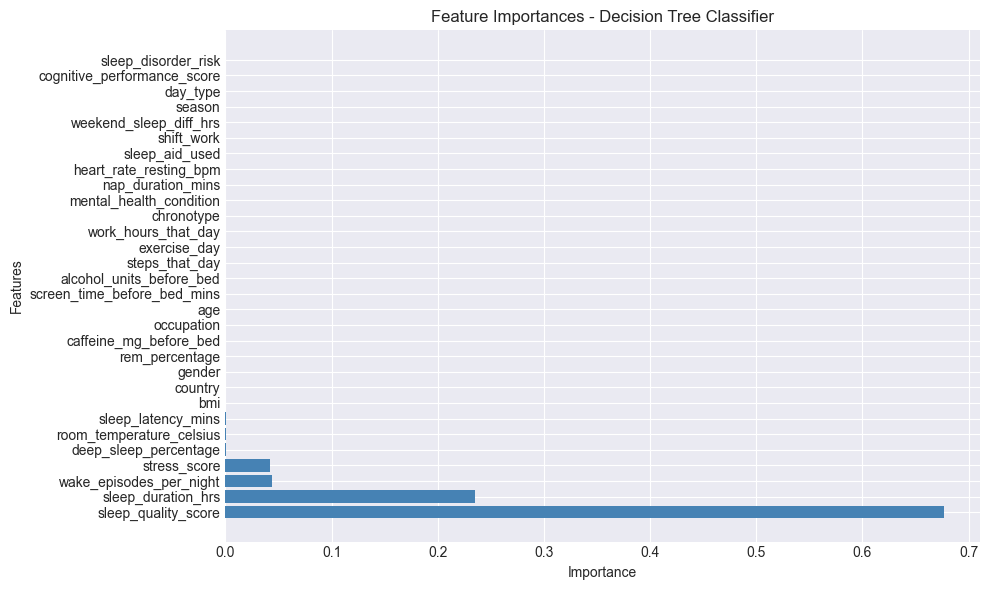

In [7]:
# Feature importances
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nWaznosc cech (Feature Importances):")
print(feature_importances)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['feature'], feature_importances['importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importances - Decision Tree Classifier')
plt.tight_layout()
plt.show()


## PREDYKCJE I OCENA MODELU


In [8]:
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

print("\n" + "=" * 70)
print("METRYKI KLASYFIKACJI NA ZBIORZE TESTOWYM")
print("=" * 70)



METRYKI KLASYFIKACJI NA ZBIORZE TESTOWYM


In [9]:
# Obliczenie metryk
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print(f"\nAccuracy (dokladnosc):  {accuracy:.4f}")
print(f"Precision (precyzja):   {precision:.4f}")
print(f"Recall (czulosc):       {recall:.4f}")
print(f"F1 Score:               {f1:.4f}")



Accuracy (dokladnosc):  0.7329
Precision (precyzja):   0.7299
Recall (czulosc):       0.7329
F1 Score:               0.7306


In [10]:
# Szczegolowy raport klasyfikacji
print("\n" + "-" * 70)
print("RAPORT KLASYFIKACJI NA ZBIORZE TESTOWYM:")
print("-" * 70)
if le_target is not None:
    target_names = le_target.classes_
else:
    target_names = [str(i) for i in sorted(np.unique(y_test))]

print(classification_report(y_test, y_test_pred, target_names=target_names))



----------------------------------------------------------------------
RAPORT KLASYFIKACJI NA ZBIORZE TESTOWYM:
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.81      0.79     12198
           1       0.67      0.62      0.64      7802

    accuracy                           0.73     20000
   macro avg       0.72      0.71      0.71     20000
weighted avg       0.73      0.73      0.73     20000




Macierz pomylek (Confusion Matrix):
[[9839 2359]
 [2984 4818]]


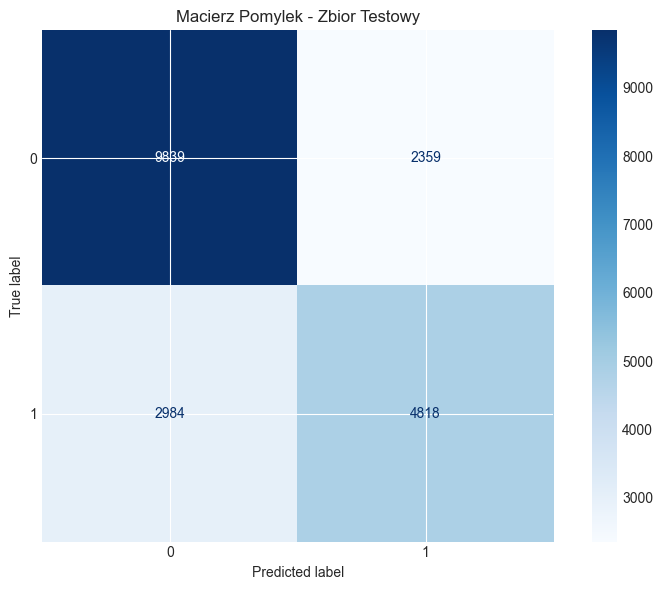

In [11]:
# Macierz pomylek (Confusion Matrix)
cm = confusion_matrix(y_test, y_test_pred)
print("\nMacierz pomylek (Confusion Matrix):")
print(cm)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, cmap='Blues')
ax.set_title('Macierz Pomylek - Zbior Testowy')
plt.tight_layout()
plt.show()


In [12]:
# Metryki dla kazdej klasy oddzielnie (dla niezbalansowanych danych)
print("\n" + "-" * 70)
print("METRYKI DLA KAZDEJ KLASY (wazne dla niezbalansowanych danych):")
print("-" * 70)

precision_per_class = precision_score(y_test, y_test_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_test, y_test_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_test, y_test_pred, average=None, zero_division=0)

for i, class_name in enumerate(target_names):
    print(f"\nKlasa: {class_name}")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall:    {recall_per_class[i]:.4f}")
    print(f"  F1 Score:  {f1_per_class[i]:.4f}")



----------------------------------------------------------------------
METRYKI DLA KAZDEJ KLASY (wazne dla niezbalansowanych danych):
----------------------------------------------------------------------

Klasa: 0
  Precision: 0.7673
  Recall:    0.8066
  F1 Score:  0.7865

Klasa: 1
  Precision: 0.6713
  Recall:    0.6175
  F1 Score:  0.6433


In [13]:
# Porownanie metryk na zbiorze treningowym vs testowym
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("\n" + "=" * 70)
print("POROWNANIE: ZBIOR TRENINGOWY vs TESTOWY")
print("=" * 70)
print(f"\n{'Metryka':<20} {'Train':<15} {'Test':<15} {'Roznica':<15}")
print("-" * 60)
print(f"{'Accuracy':<20} {train_accuracy:<15.4f} {test_accuracy:<15.4f} {train_accuracy - test_accuracy:<15.4f}")
print(f"{'F1 Score':<20} {train_f1:<15.4f} {test_f1:<15.4f} {train_f1 - test_f1:<15.4f}")



POROWNANIE: ZBIOR TRENINGOWY vs TESTOWY

Metryka              Train           Test            Roznica        
------------------------------------------------------------
Accuracy             0.7363          0.7329          0.0035         
F1 Score             0.7341          0.7306          0.0035         


## WIZUALIZACJA DRZEWA DECYZYJNEGO



WIZUALIZACJA DRZEWA DECYZYJNEGO


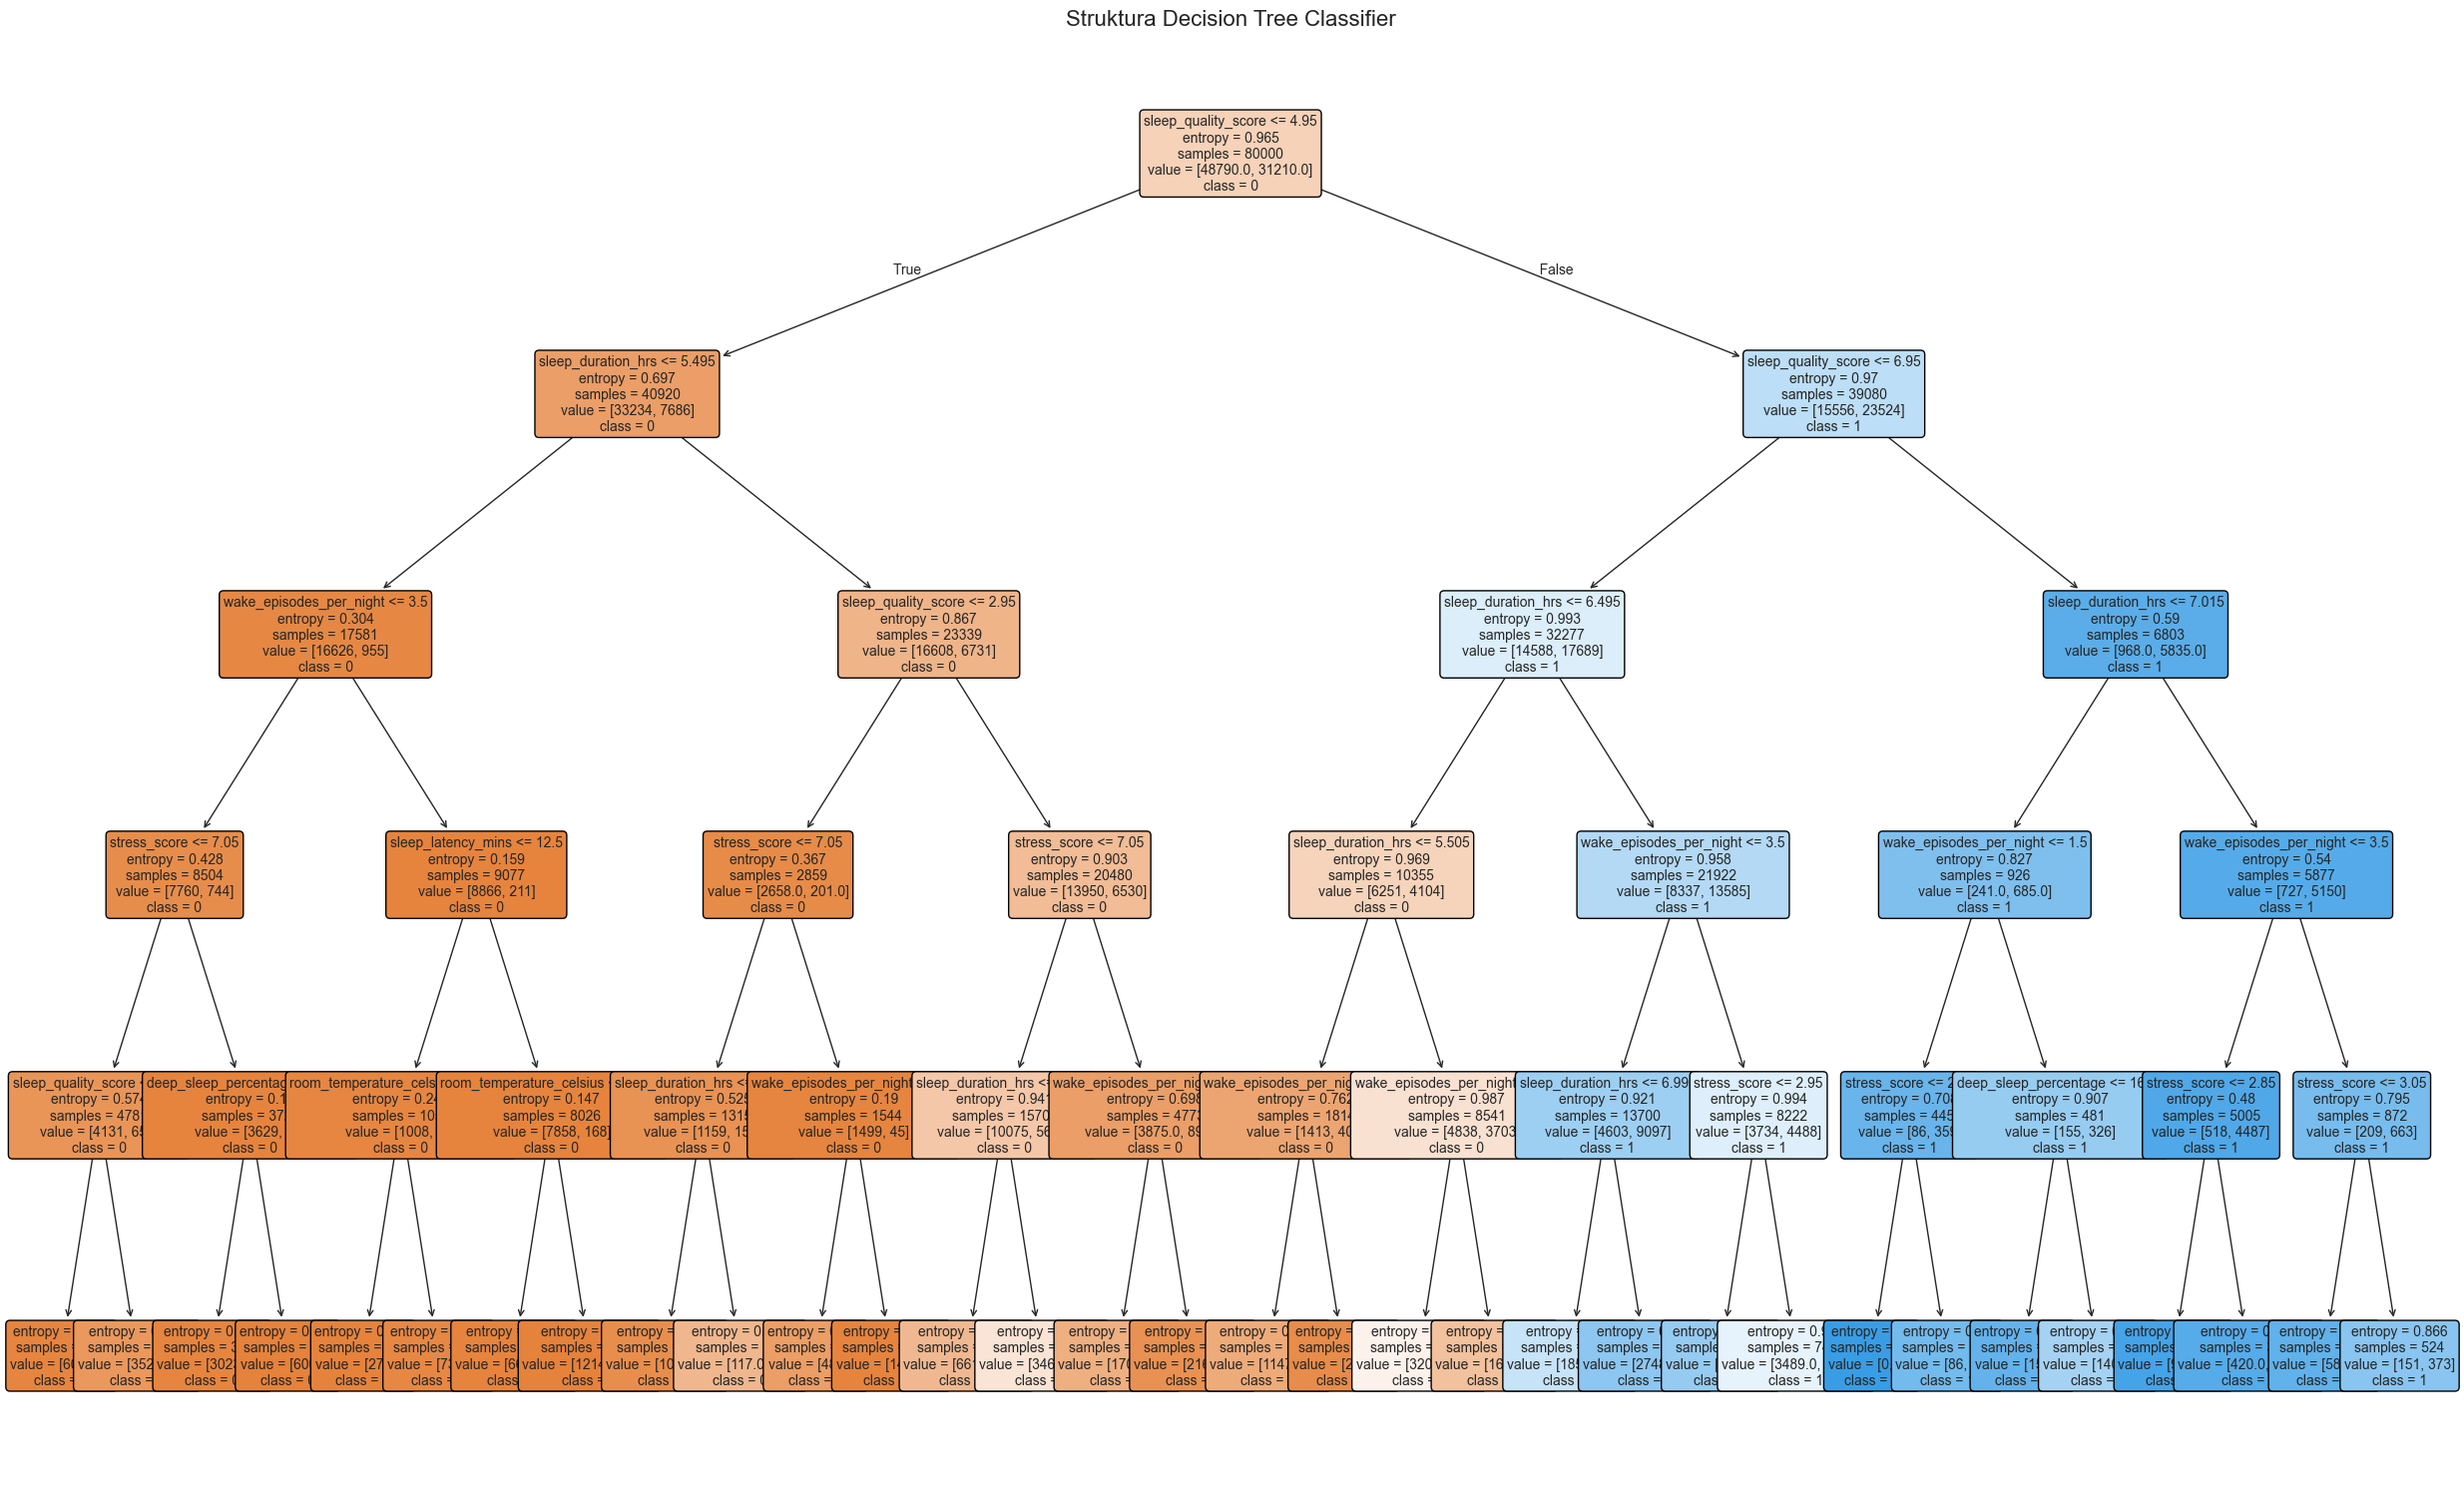

In [14]:
print("\n" + "=" * 70)
print("WIZUALIZACJA DRZEWA DECYZYJNEGO")
print("=" * 70)

plt.figure(figsize=(25, 15))
plot_tree(dt_classifier,
          feature_names=X_train.columns.tolist(),
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Struktura Decision Tree Classifier', fontsize=16)
plt.tight_layout()
plt.show()


In [15]:
# Eksport regul tekstowych
print("\nREGULY TEKSTOWE DRZEWA DECYZYJNEGO:")
print("=" * 70)
tree_rules = export_text(dt_classifier, feature_names=X_train.columns.tolist())
print(tree_rules)



REGULY TEKSTOWE DRZEWA DECYZYJNEGO:
|--- sleep_quality_score <= 4.95
|   |--- sleep_duration_hrs <= 5.49
|   |   |--- wake_episodes_per_night <= 3.50
|   |   |   |--- stress_score <= 7.05
|   |   |   |   |--- sleep_quality_score <= 2.95
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- sleep_quality_score >  2.95
|   |   |   |   |   |--- class: 0
|   |   |   |--- stress_score >  7.05
|   |   |   |   |--- deep_sleep_percentage <= 23.45
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- deep_sleep_percentage >  23.45
|   |   |   |   |   |--- class: 0
|   |   |--- wake_episodes_per_night >  3.50
|   |   |   |--- sleep_latency_mins <= 12.50
|   |   |   |   |--- room_temperature_celsius <= 18.65
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- room_temperature_celsius >  18.65
|   |   |   |   |   |--- class: 0
|   |   |   |--- sleep_latency_mins >  12.50
|   |   |   |   |--- room_temperature_celsius <= 23.65
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- room_tempera

## PODSUMOWANIE MODELU


In [16]:
print("\n" + "=" * 70)
print("PODSUMOWANIE MODELU")
print("=" * 70)
print(f"\nModel: Decision Tree Classifier")
print(f"Liczba cech: {X_train.shape[1]}")
print(f"Liczba probek treningowych: {X_train.shape[0]}")
print(f"Liczba probek testowych: {X_test.shape[0]}")
print(f"Liczba klas: {len(target_names)}")
print(f"Glebokosc drzewa: {dt_classifier.get_depth()}")
print(f"Liczba lisci: {dt_classifier.get_n_leaves()}")
print("\nWyniki na zbiorze testowym:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print("\n" + "=" * 70)
print("ZAKONCZENINE ANALIZY")
print("=" * 70)




PODSUMOWANIE MODELU

Model: Decision Tree Classifier
Liczba cech: 30
Liczba probek treningowych: 80000
Liczba probek testowych: 20000
Liczba klas: 2
Glebokosc drzewa: 5
Liczba lisci: 32

Wyniki na zbiorze testowym:
  Accuracy:  0.7329
  Precision: 0.7299
  Recall:    0.7329
  F1 Score:  0.7306

ZAKONCZENINE ANALIZY
